# DBGSOM Paper Benchmarks

Reproducible results for the JOSS paper. Run the scripts first:

```bash
uv run python paper_benchmarks/clustering.py
uv run python paper_benchmarks/scaling.py
```


In [43]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

RESULTS = Path("results")

## Clustering — Digits dataset


In [44]:
df_cluster = pd.read_csv(RESULTS / "clustering_digits.csv", index_col="Algorithm")
df_cluster

,n_prototypes,Time (s),QE,TE,ARI,Silhouette
Algorithm,,,,,,
DBGSOM,56,0.906,4.8073,0.1858,0.285,0.044
MiniSom,64,32.675,4.6633,—,0.241,0.075
SuSi,64,0.110,5.9120,—,0.359,-0.035


## Scaling — training time vs. N


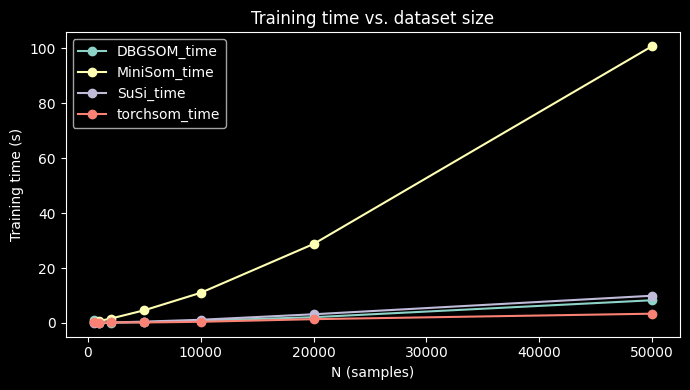

,DBGSOM_time,DBGSOM_n_nodes,DBGSOM_qe,DBGSOM_te,MiniSom_time,MiniSom_n_nodes,MiniSom_qe,SuSi_time,SuSi_n_nodes,SuSi_qe,torchsom_time,torchsom_n_nodes,torchsom_qe
N,,,,,,,,,,,,,
500,1.217,9,4.1834,0.1380,0.372,9,4.1534,0.040,9,4.2605,0.490,9,4.1488
1000,0.029,19,4.0914,0.1710,0.732,25,3.9102,0.080,25,4.1346,0.067,25,4.0918
2000,0.080,43,3.9900,0.1445,1.576,49,3.7836,0.171,49,4.0648,0.220,49,4.0941
5000,0.300,133,3.8057,0.1744,4.627,144,3.5684,0.490,144,3.9130,0.181,144,4.0841
10000,0.826,251,3.7160,0.1878,10.999,256,3.4754,1.168,256,3.8413,0.430,256,4.0732
20000,2.099,443,3.6315,0.2098,28.767,484,3.3687,3.171,484,3.7465,1.383,484,4.0455
50000,8.271,840,3.5445,0.2256,100.816,841,3.3162,9.918,841,3.6611,3.377,841,4.0444


In [45]:
df_scale = pd.read_csv(RESULTS / "scaling.csv", index_col="N")
times = ["DBGSOM_time", "MiniSom_time", "SuSi_time", "torchsom_time"]

fig, ax = plt.subplots(figsize=(7, 4))
for col in df_scale[times]:
    ax.plot(df_scale.index, df_scale[col], marker="o", label=col)

ax.set_xlabel("N (samples)")
ax.set_ylabel("Training time (s)")
ax.set_title("Training time vs. dataset size")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS / "scaling_plot.png", dpi=150)
plt.show()
df_scale

In [46]:
df_scale[times]

,DBGSOM_time,MiniSom_time,SuSi_time,torchsom_time
N,,,,
500,1.217,0.372,0.040,0.490
1000,0.029,0.732,0.080,0.067
2000,0.080,1.576,0.171,0.220
5000,0.300,4.627,0.490,0.181
10000,0.826,10.999,1.168,0.430
20000,2.099,28.767,3.171,1.383
50000,8.271,100.816,9.918,3.377
